# Лабораторная работа №5
## Выполнил студент группы Козырев Матвей Андреевич БВТ2301

### Оглавление
1. [Задание 1](#Задание-№1)
2. [Задание 2](#Задание-№2)
4. [Вывод](#Вывод)

> Дополнительные модули, использованные при выполнение лабораторной

In [18]:
import time as t

### Задание №1
Реализовать методы поиска подстроки в строке. Добавить возможность ввода строки и подстроки с клавиатуры. Предусмотреть возможность существования пробела. Реализовать возможность выбора опции чувствительности или нечувствительности к регистру. Оценить время работы каждого алгоритма поиска и сравнить его со временем работы стандартной функции поиска, используемой в выбранном языке программирования.

In [19]:
import matplotlib.pyplot as plt
# Построение графика
def sort_plot(sizes,time_standard,time):
  print(sizes)
  print(time_standard)
  print(time)
  plt.plot(sizes, time, label="Выбранный поиск", color='green')
  plt.plot(sizes, time_standard, label="Стандартная сортировка", color = 'blue')
  plt.xlabel('Размер текста')
  plt.ylabel('Время выполнения (милисекунды)')
  plt.title('Сравнение времени выполнения сортировки')
  plt.legend()
  plt.grid(True)
  plt.show()

In [25]:
def standard_search(text, pattern, case_sensitive=True):
    """
    Стандартный поиск с использованием встроенных функций Python
    """
    start_time = t.time()

    if not case_sensitive:
        text = text.lower()
        pattern = pattern.lower()

    position = text.find(pattern)

    elapsed_time = (t.time() - start_time) * 1000

    print(f"--- {elapsed_time} ms ---")
    return elapsed_time

In [31]:
text = 'abababababbdasdasdbbasbd'
pattern = 'bdasd'
text.find(pattern)

10

#### Алгоритм Кнута-Морриса-Пратта

In [23]:
import time

def kmp_search(text, pattern, case_sensitive=True):
    if not case_sensitive:
        text = text.lower()
        pattern = pattern.lower()

    def compute_prefix(pattern):
        prefix = [0] * len(pattern)
        j = 0
        for i in range(1, len(pattern)):
            while j > 0 and pattern[i] != pattern[j]:
                j = prefix[j - 1]
            if pattern[i] == pattern[j]:
                j += 1
            prefix[i] = j
        return prefix

    start_time = time.time()
    prefix = compute_prefix(pattern)
    matches = []
    j = 0
    for i in range(len(text)):
        while j > 0 and text[i] != pattern[j]:
            j = prefix[j - 1]
        if text[i] == pattern[j]:
            j += 1
        if j == len(pattern):
            matches.append(i - j + 1)
            j = prefix[j - 1]
    end_time = time.time()
    print(f"--- {(end_time - start_time) * 1000} ms ---")
    return (end_time - start_time) * 1000

Сколько раз вы хотите тестировать поиск? 10
---Тест номер 1---
Введите текст: Hello
Введите подстроку: ell
--- 0.001430511474609375 ms ---
--- 0.009775161743164062 ms ---
---Тест 1 окончен---
---Тест номер 2---
Введите текст: Hello world
Введите подстроку: o w
--- 0.001430511474609375 ms ---
--- 0.011920928955078125 ms ---
---Тест 2 окончен---
---Тест номер 3---
Введите текст: Hello world, this is a test.
Введите подстроку: a te
--- 0.0019073486328125 ms ---
--- 0.01430511474609375 ms ---
---Тест 3 окончен---
---Тест номер 4---
Введите текст: Hello world, this is a test. Testing string search algorithms.
Введите подстроку: ithms
--- 0.0019073486328125 ms ---
--- 0.023126602172851562 ms ---
---Тест 4 окончен---
---Тест номер 5---
Введите текст: Hello world, this is a test. Testing string search algorithms. Algorithms are important in computer science.
Введите подстроку: ter scien
--- 0.0019073486328125 ms ---
--- 0.029087066650390625 ms ---
---Тест 5 окончен---
---Тест номер 6---
Введит

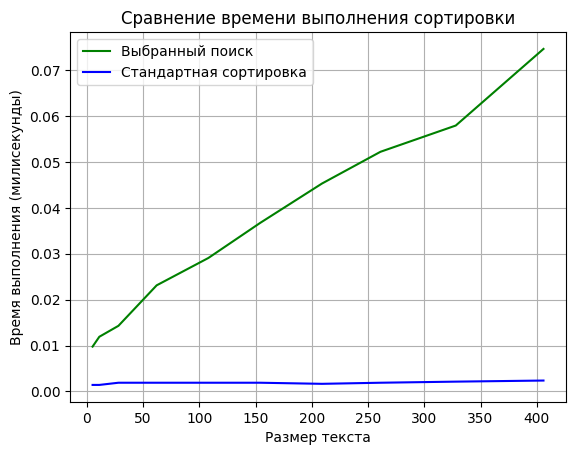

In [27]:
n = int(input('Сколько раз вы хотите тестировать поиск? '))
time_standard = []
time_kmp = []
sizes = []
for i in range(n):
  print(f'---Тест номер {i + 1}---')
  text = input('Введите текст: ')
  pattern = input('Введите подстроку: ')


  sizes.append(len(text))
  time_standard.append(standard_search(text, pattern))
  time_kmp.append(kmp_search(text, pattern))

  print(f'---Тест {i + 1} окончен---')

sort_plot(sizes, time_standard, time_kmp)

#### Упрощенный алгоритм Бойера-Мура

In [ ]:
def simplified_boyer_moore(text, pattern, case_sensitive=True):
    """
    Упрощенный алгоритм Бойера-Мура
    """
    start_time = t.time()

    if not case_sensitive:
        text = text.lower()
        pattern = pattern.lower()

    def bad_char_heuristic(pat):
        bad_char = {}
        for i in range(len(pat)):
            bad_char[pat[i]] = i
        return bad_char

    bad_char = bad_char_heuristic(pattern)
    m = len(pattern)
    n = len(text)
    s = 0

    while s <= n - m:
        j = m - 1
        while j >= 0 and pattern[j] == text[s + j]:
            j -= 1
        if j < 0:
            print("--- {0} ms ---".format((t.time() - start_time)*1000))
            return (t.time() - start_time)*1000
        else:
            s += max(1, j - bad_char.get(text[s + j], -1))
    print("--- {0} ms ---".format((t.time() - start_time)*1000))
    return (t.time() - start_time)*1000

Сколько раз вы хотите тестировать сортировку? 10
---Тест номер 1---
Введите текст: Hello
Введите подстроку: ell
--- 0.0011920928955078125 ms ---
--- 0.017881393432617188 ms ---
---Тест 1 окончен---
---Тест номер 2---
Введите текст: Hello world
Введите подстроку: orl
--- 0.0016689300537109375 ms ---
--- 0.0286102294921875 ms ---
---Тест 2 окончен---
---Тест номер 3---
Введите текст: Hello world, this is a test.
Введите подстроку: a tes
--- 0.0011920928955078125 ms ---
--- 0.016689300537109375 ms ---
---Тест 3 окончен---
---Тест номер 4---
Введите текст: Hello world, this is a test. Testing string search algorithms.
Введите подстроку: gorithm
--- 0.0016689300537109375 ms ---
--- 0.02193450927734375 ms ---
---Тест 4 окончен---
---Тест номер 5---
Введите текст: Hello world, this is a test. Testing string search algorithms. Algorithms are important in computer science.
Введите подстроку: cien
--- 0.00095367431640625 ms ---
--- 0.030755996704101562 ms ---
---Тест 5 окончен---
---Тест номер 6

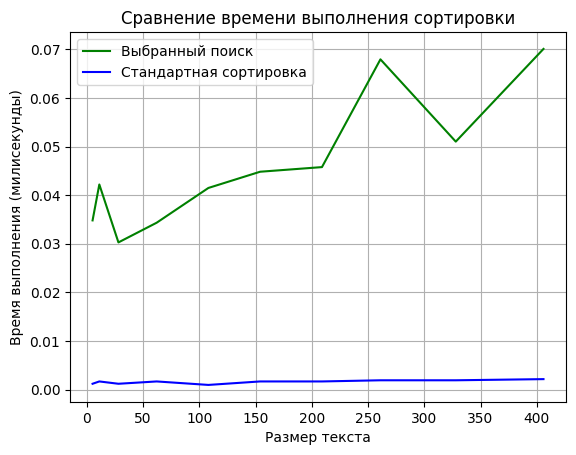

In [28]:
n = int(input('Сколько раз вы хотите тестировать сортировку? '))
time_standard = []
time_boyer_moore = []
sizes = []
for i in range(n):
  print(f'---Тест номер {i + 1}---')
  text = input('Введите текст: ')
  pattern = input('Введите подстроку: ')

  sizes.append(len(text))
  time_standard.append(standard_search(text, pattern))
  time_boyer_moore.append(simplified_boyer_moore(text, pattern))

  print(f'---Тест {i + 1} окончен---')

sort_plot(sizes, time_standard, time_boyer_moore)

### Задание №2
Написать программу, определяющую, является ли данное
расположение «решаемым», то есть можно ли из него за конечное число
шагов перейти к правильному. Если это возможно, то необходимо найти хотя
бы одно решение - последовательность движений, после которой числа будут
расположены в правильном порядке.
#### Входные данные: массив чисел, представляющий собой расстановку в
Порядке «слева направо, сверху вниз». Число 0 обозначает пустое поле.
Например, массив [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 0] представляет
собой «решенную» позицию элементов.
#### Выходные данные: если решения нет, то функция должна вернуть
Пустой массив []. Если решение есть, то необходимо представить решение —
для каждого шага записывается номер передвигаемого на данном шаге
элемента.

In [51]:
import heapq

def count_inversions(arr):
    """Подсчет количества инверсий в массиве (игнорируя 0)"""
    inversions = 0
    n = len(arr)
    for i in range(n):
        if arr[i] == 0:
            continue
        for j in range(i + 1, n):
            if arr[j] != 0 and arr[i] > arr[j]:
                inversions += 1
    return inversions

def is_solvable(puzzle):
    """Проверка, можно ли решить данный пазл"""
    size = int(len(puzzle) ** 0.5)
    inversions = count_inversions(puzzle)
    zero_pos = puzzle.index(0)
    zero_row = zero_pos // size

    if size % 2 == 1:
        return inversions % 2 == 0
    else:
        return (inversions + zero_row) % 2 == 1

def solve_puzzle(start_state):
    """Решение головоломки с использованием A* алгоритма"""
    size = int(len(start_state) ** 0.5)
    goal_state = list(range(1, size*size)) + [0]

    def heuristic(state):
        """Манхэттенское расстояние для всех плиток"""
        distance = 0
        for i in range(len(state)):
            if state[i] == 0:
                continue
            goal_pos = goal_state.index(state[i])
            x1, y1 = i % size, i // size
            x2, y2 = goal_pos % size, goal_pos // size
            distance += abs(x1 - x2) + abs(y1 - y2)
        return distance

    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    visited = set()
    heap = []
    heapq.heappush(heap, (heuristic(start_state), 0, start_state, []))

    while heap:
        _, cost, current_state, path = heapq.heappop(heap)

        if current_state == goal_state:
            return path

        if tuple(current_state) in visited:
            continue
        visited.add(tuple(current_state))

        zero_pos = current_state.index(0)
        zero_x, zero_y = zero_pos % size, zero_pos // size

        for dx, dy in directions:
            new_x, new_y = zero_x + dx, zero_y + dy
            if 0 <= new_x < size and 0 <= new_y < size:
                new_pos = new_y * size + new_x
                new_state = current_state[:]
                new_state[zero_pos], new_state[new_pos] = new_state[new_pos], new_state[zero_pos]

                if tuple(new_state) not in visited:
                    moved_number = current_state[new_pos]
                    heapq.heappush(
                        heap,
                        (
                            cost + 1 + heuristic(new_state),
                            cost + 1,
                            new_state,
                            path + [moved_number]
                        )
                    )

    return []

def solve_15_puzzle(start_state):
    """Основная функция для решения 15-пазла"""
    if len(start_state) != 16 or sorted(start_state) != list(range(16)):
        raise ValueError("Некорректное начальное состояние пазла")

    if not is_solvable(start_state):
        return []

    return solve_puzzle(start_state)


start_state_1 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 0, 15]
start_state_2 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 14, 0]
start_state_3 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0, 13, 14, 15, 12]
start_state_4 = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0, 12, 13, 14, 11, 15]

for i, state in enumerate([start_state_1, start_state_2, start_state_3, start_state_4], 1):
    print(f"\nПример {i}: {state}")
    solution = solve_15_puzzle(state)
    if solution:
        print(f"Решение найдено, количество шагов: {len(solution)}")
        print(f"Перемещаемые элементы: {solution}")
    else:
        print("Решение не существует.")


Пример 1: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 0, 15]
Решение найдено, количество шагов: 1
Перемещаемые элементы: [15]

Пример 2: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15, 14, 0]
Решение не существует.

Пример 3: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0, 13, 14, 15, 12]
Решение найдено, количество шагов: 1
Перемещаемые элементы: [12]

Пример 4: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 0, 12, 13, 14, 11, 15]
Решение найдено, количество шагов: 2
Перемещаемые элементы: [11, 15]
